In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 


path = os.getcwd()

aln = ALNModel()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

[[5.0914e-04 2.6086e+01]
 [3.7674e+01 9.4217e+01]]
high state vars =  [ 4.1442e+001  1.0364e+002  1.4940e+000  3.5072e+000  0.0000e+000
  9.6970e-001  1.0280e+000  9.6173e-001  1.0630e+000  8.8827e-004
  3.5919e-004  9.2329e-004  2.1508e-004  2.6652e-264  1.9989e-264
  1.6517e+000  1.6511e+000 -6.2344e+001  1.6456e+000  4.8514e-001]


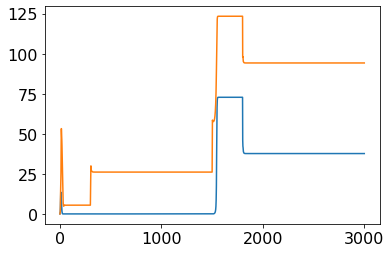

In [13]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.1
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.1

print("high state vars = ", high_state_vars)

low state vars =  [ 7.5570e-005  2.3497e+001 -3.0066e-001  9.3877e-001  0.0000e+000
  1.4927e-005  7.1839e-001  1.3951e-005  7.9955e-001  9.2140e-007
  2.3586e-003  8.0485e-007  1.7561e-003  2.1806e-264  1.6354e-264
  1.3664e+000  1.3517e+000 -6.4518e+001  1.9230e+001  2.0962e+000]


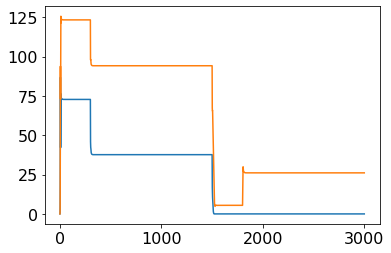

In [15]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.9
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.9

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [5]:
aln = ALNModel()

dur = 50
dur_pre = 20
dur_post = 20
aln.params.duration = dur

# NO ADAPTATION
#aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = steady_rates[0,0]
target[:,1,:] = steady_rates[0,1]
    
#aln.params.rates_exc_init = np.array([[ np.mean(steady_rates[:,0]) ]])
#aln.params.rates_inh_init = np.array([[ np.mean(steady_rates[:,1]) ]])
                
#for init in aln.init_vars:
#    aln.params[init] = np.zeros(aln.params[init].shape)
#steady_state_vars = np.zeros(( len(state_vars) ))

# still set to those values    
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

#output = aln.output_vars

max_it = 250
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 1000.
test_step = 1e-6

In [7]:
#aln.params.signalV = 20.
#aln.params.de = 0.1
#aln.params.di = 0.1

# A: precision only, free choice of control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            #print("init vars : ", init_vars[iv])
            #print(aln.params[init_vars[iv]])
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultA = {"Opt_control": A2_bestControlA,
          "Opt_state": A2_bestStateA,
          "costArray": A2_costA,
          "runtimeArray": A2_runtimeA,    
}

dump_dicts = [opt_params, aln.params, resultA]
pickle.dump( dump_dicts, open( "A.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151834.8189200733
RUN  1 , total integrated cost:  3165.2719853892804
RUN  2 , total integrated cost:  2183.328548652384
RUN  3 , total integrated cost:  2088.7030891640647
RUN  4 , total integrated cost:  1851.3463174193776
RUN  5 , total integrated cost:  1805.6100166228691
RUN  6 , total integrated cost:  1375.5790655013918
RUN  7 , total integrated cost:  1156.6606960745385
RUN  8 , total integrated cost:  946.0241729235418
RUN  9 , total integrated cost:  658.4797488033716
RUN  10 , total integrated cost:  640.7780398807513
RUN  11 , total integrated cost:  624.1194750568937
RUN  12 , total integrated cost:  619.633437152475
RUN  13 , total integrated cost:  616.2690002612765
RUN  14 , total integrated cost:  613.0397713297283
RUN  15 , total integrated cost:  610.8460825729198
RUN  16 , total integrated cost:  609.6308532343037
RUN  17 , total integrated cost:  608.6846185069797
RUN  18 , total integrated cost:  608

RUN  157 , total integrated cost:  606.3050444329373
RUN  158 , total integrated cost:  606.3050442708774
RUN  159 , total integrated cost:  606.305044128591
RUN  160 , total integrated cost:  606.3050439984466
RUN  161 , total integrated cost:  606.3050438723504
RUN  162 , total integrated cost:  606.3050437614587
RUN  163 , total integrated cost:  606.3050436589647
RUN  164 , total integrated cost:  606.3050435702824
RUN  165 , total integrated cost:  606.3050434865881
RUN  166 , total integrated cost:  606.3050434117206
RUN  167 , total integrated cost:  606.3050433455403
RUN  168 , total integrated cost:  606.3050432887733
RUN  169 , total integrated cost:  606.3050432275552
RUN  170 , total integrated cost:  606.3050431759568
RUN  171 , total integrated cost:  606.3050431236261
RUN  172 , total integrated cost:  606.305043078865
RUN  173 , total integrated cost:  606.3050430408753
RUN  174 , total integrated cost:  606.3050430060428
RUN  175 , total integrated cost:  606.305042974

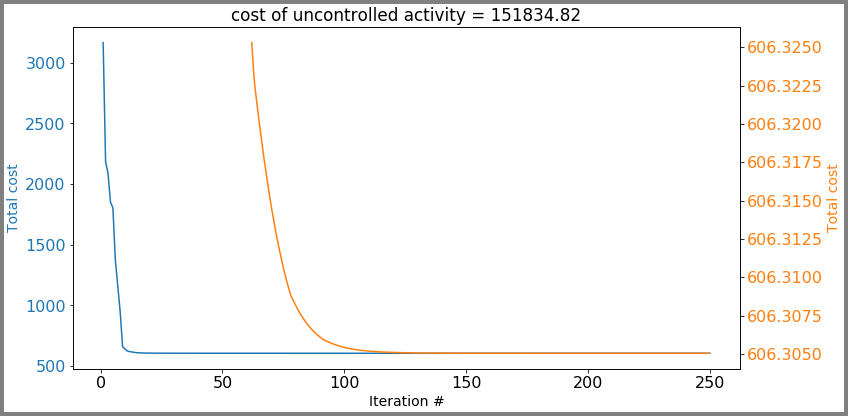

In [43]:
plotFunc.plot_convergence(A2_costA, path, filename_ = 'p1_e0_uInf_HighLow_cost', ratio_ = 0.25)

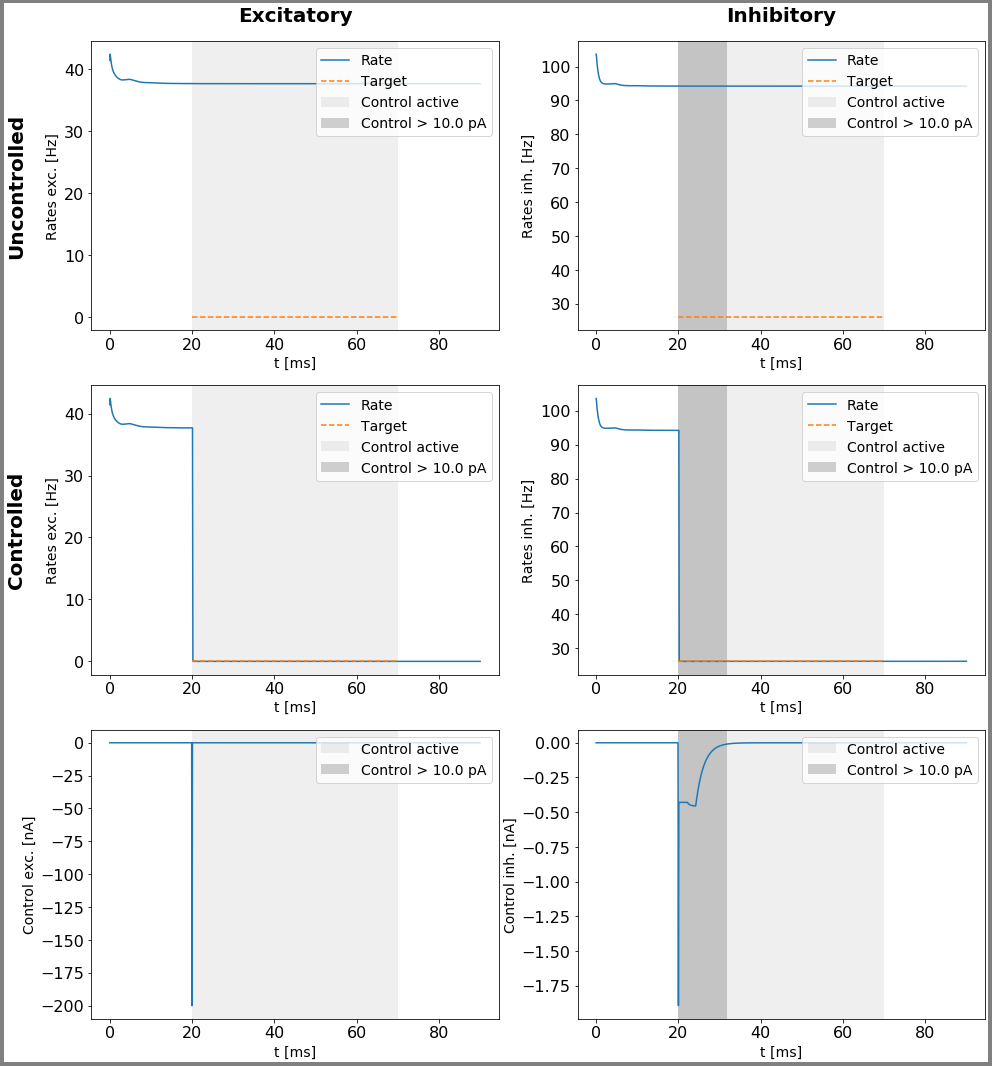

In [51]:
plotFunc.plot_control(aln, A2_bestControlA, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = 'p1_e0_uInf_HighLow')

In [8]:
# B: precision only, max 1nA control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

A2_bestControlB, A2_bestStateB, A2_costB, A2_runtimeB = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultB = {"Opt_control": A2_bestControlB,
          "Opt_state": A2_bestStateB,
          "costArray": A2_costB,
          "runtimeArray": A2_runtimeB,    
}

dump_dicts = [opt_params, aln.params, resultB]
pickle.dump( dump_dicts, open( "B.p", "wb" ) )

set cost params
0
0 0.0
start ind =  41
0
0 0.0
0
0 0.0
RUN  0 , total integrated cost:  151834.8189201053
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0

0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0


0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  1
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  2
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  1
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 

0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  1
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 

0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  4
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 

...

0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  1
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 

0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  4
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  2
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0


0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
change helped, counter =  2
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 

0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0
0
0 0.0


KeyboardInterrupt: 

In [7]:
plotFunc.plot_convergence(A2_costB, path, "p1_e0_u1nA_HighLow_cost")

NameError: name 'A2_costB' is not defined

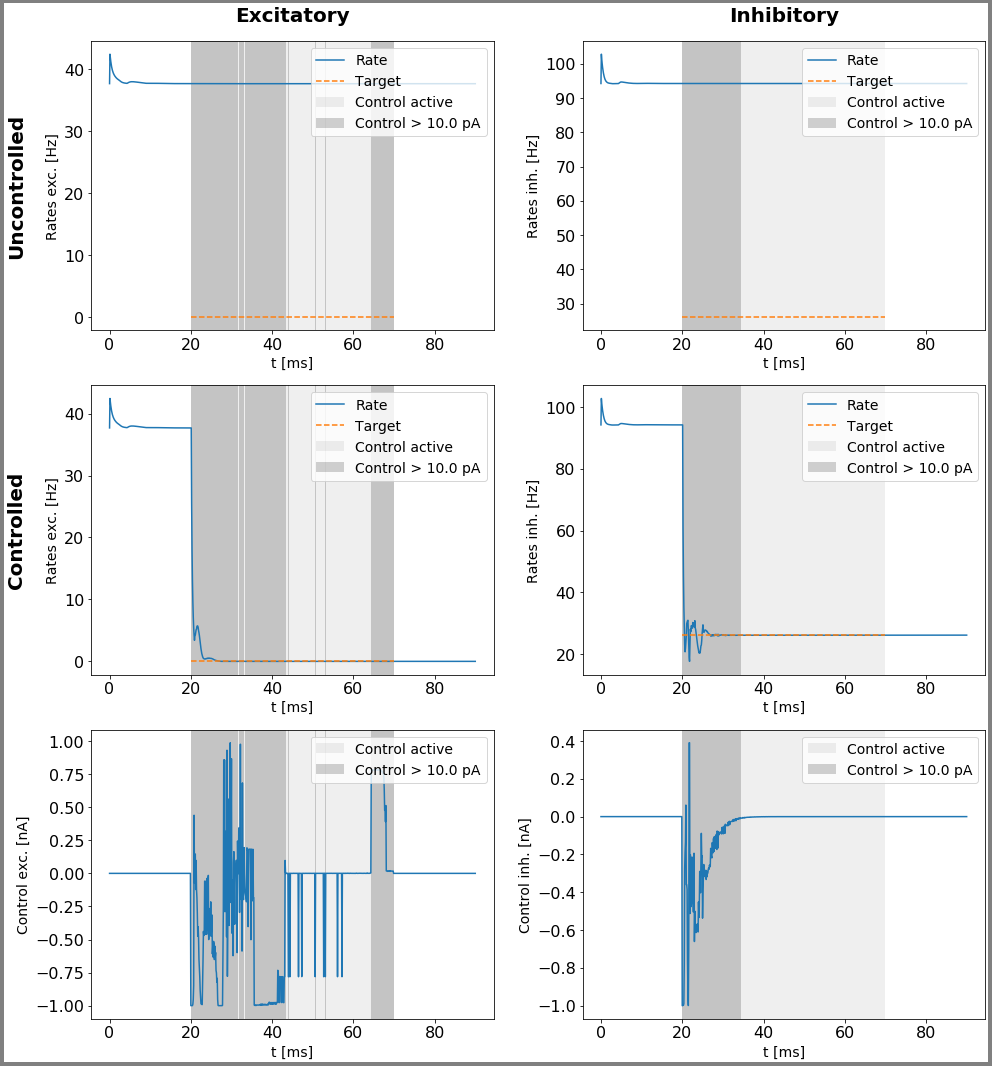

In [55]:
plotFunc.plot_control(A2_bestControlB, dur, dur_pre, dur_post, high_state_vars, target, path, filename = 'p1_e0_u1nA_HighLow')

In [13]:
# C: precision & energy equally penalize, free choice of control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

A2_bestControlC, A2_bestStateC, A2_costC, A2_runtimeC = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultC = {"Opt_control": A2_bestControlC,
          "Opt_state": A2_bestStateC,
          "costArray": A2_costC,
          "runtimeArray": A2_runtimeC,    
}

dump_dicts = [opt_params, aln.params, resultC]
pickle.dump( dump_dicts, open( "C.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151832.83521440506
RUN  1 , total integrated cost:  3241.1128734455
RUN  2 , total integrated cost:  2406.016666309559
RUN  3 , total integrated cost:  2327.9600808920727
RUN  4 , total integrated cost:  1849.5720727319783
RUN  5 , total integrated cost:  1750.9771834822018
RUN  6 , total integrated cost:  1479.0812070900304
RUN  7 , total integrated cost:  1182.2878371106478
RUN  8 , total integrated cost:  991.5105502253427
RUN  9 , total integrated cost:  927.2677142854169
RUN  10 , total integrated cost:  917.9784339741045
RUN  11 , total integrated cost:  721.5795309215079
RUN  12 , total integrated cost:  717.9513945020894
RUN  13 , total integrated cost:  714.2182542168536
RUN  14 , total integrated cost:  711.0418507473914
RUN  15 , total integrated cost:  708.2343622417969
RUN  16 , total integrated cost:  705.8746113148368
RUN  17 , total integrated cost:  703.981559621866
RUN  18 , total integrated cost:  702.2

RUN  157 , total integrated cost:  672.3124742195728
RUN  158 , total integrated cost:  672.212756959243
RUN  159 , total integrated cost:  672.1112365823434
RUN  160 , total integrated cost:  672.0106558046743
RUN  161 , total integrated cost:  671.9115431038659
RUN  162 , total integrated cost:  671.8074153452253
RUN  163 , total integrated cost:  671.7021051515783
RUN  164 , total integrated cost:  671.5970461544506
RUN  165 , total integrated cost:  671.4957509126165
RUN  166 , total integrated cost:  671.3945622307451
RUN  167 , total integrated cost:  671.2918268126663
RUN  168 , total integrated cost:  671.1930057718947
RUN  169 , total integrated cost:  671.0994902482364
RUN  170 , total integrated cost:  671.0008945357423
RUN  171 , total integrated cost:  670.9065353655184
RUN  172 , total integrated cost:  670.8126175879329
RUN  173 , total integrated cost:  670.7130447373082
RUN  174 , total integrated cost:  670.6192408725275
RUN  175 , total integrated cost:  670.52975223

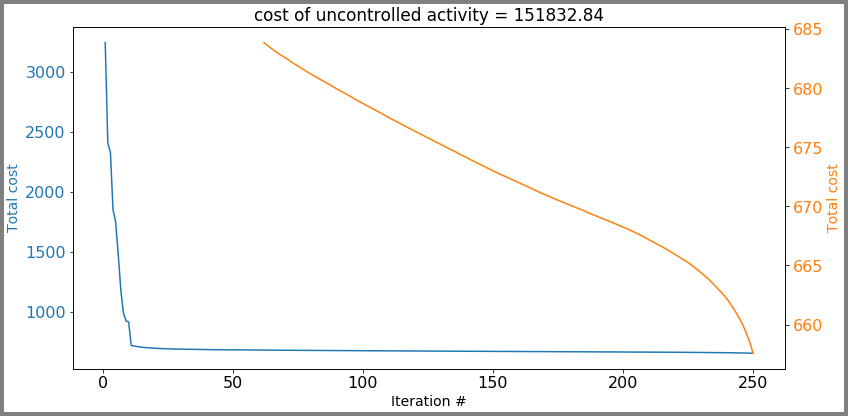

In [14]:
plot_convergence(A2_costC, "p1_e1_uInf_HighLow_cost")

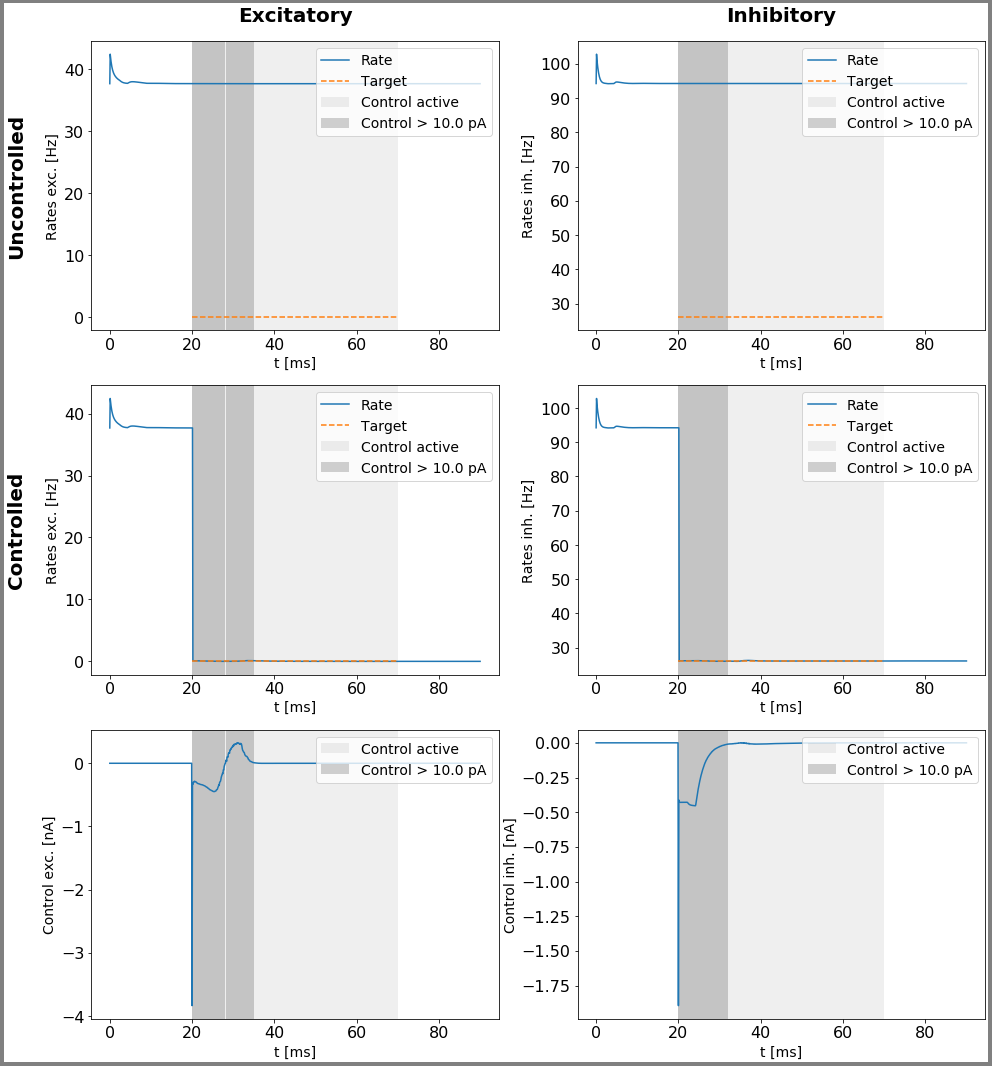

In [15]:
plot_control(A2_bestControlC, dur, dur_pre, dur_post, high_state_vars, target, filename = 'p1_e1_uInf_HighLow')

In [16]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

A2_bestControlD, A2_bestStateD, A2_costD, A2_runtimeD = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultD = {"Opt_control": A2_bestControlD,
          "Opt_state": A2_bestStateD,
          "costArray": A2_costD,
          "runtimeArray": A2_runtimeD,    
}

dump_dicts = [opt_params, aln.params, resultD]
pickle.dump( dump_dicts, open( "D.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151832.8351914085
RUN  1 , total integrated cost:  3505.521558304972
RUN  2 , total integrated cost:  1772.3112818237325
RUN  3 , total integrated cost:  1224.8254460322544
RUN  4 , total integrated cost:  1146.6770970983887
RUN  5 , total integrated cost:  1074.5397068698371
RUN  6 , total integrated cost:  1011.1278693241222
RUN  7 , total integrated cost:  946.0290564860628
RUN  8 , total integrated cost:  903.6884667642954
RUN  9 , total integrated cost:  879.8541652957915
RUN  10 , total integrated cost:  866.9233164854867
RUN  11 , total integrated cost:  859.7231562790838
RUN  12 , total integrated cost:  854.2382127769193
RUN  13 , total integrated cost:  849.1598786561656
RUN  14 , total integrated cost:  845.0330231513168
RUN  15 , total integrated cost:  841.3059543447907
RUN  16 , total integrated cost:  837.7325329587718
RUN  17 , total integrated cost:  834.2754183322935
RUN  18 , total integrated cost:  831

 max iteration reached, step size =  1.5777218104420236e-27
RUN  41 , total integrated cost:  808.6646825787606
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  42 , total integrated cost:  808.3799522064459
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  52 , total integrated cost:  806.412180950707
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  62 , total integrated cost:  804.9316455442481
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  71 , total integrated cost:  804.1136068119961
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810

...

 max iteration reached, step size =  1.5777218104420236e-27
RUN  196 , total integrated cost:  800.4721534158637
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  197 , total integrated cost:  800.4569714083373
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810442023

 max iteration reached, step size =  1.5777218104420236e-27
RUN  208 , total integrated cost:  800.2871465025794
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  209 , total integrated cost:  800.2693345090652
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810442023

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  220 , total integrated cost:  800.0954275741509
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  221 , total integrated cost:  800.0815199525662
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810442023

 max iteration reached, step size =  1.5777218104420236e-27
RUN  232 , total integrated cost:  799.924882221068
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  233 , total integrated cost:  799.9125437720384
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236

 max iteration reached, step size =  1.5777218104420236e-27
RUN  244 , total integrated cost:  799.7474398998344
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  245 , total integrated cost:  799.7315702981334
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810442023

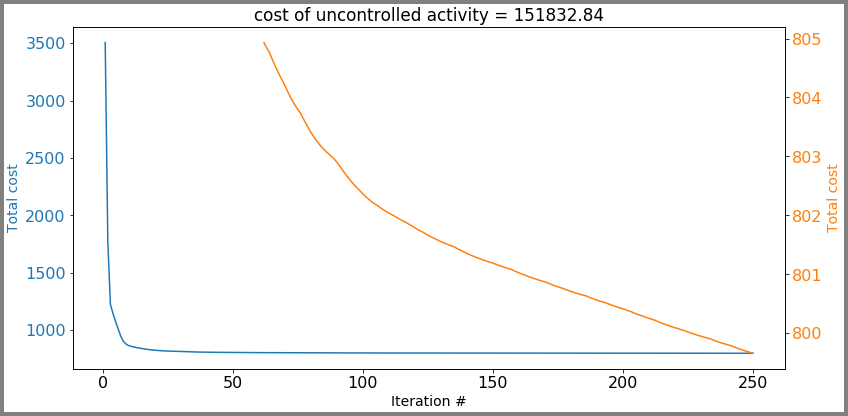

In [17]:
plot_convergence(A2_costD, "p1_e1_u1nA_HighLow_cost")

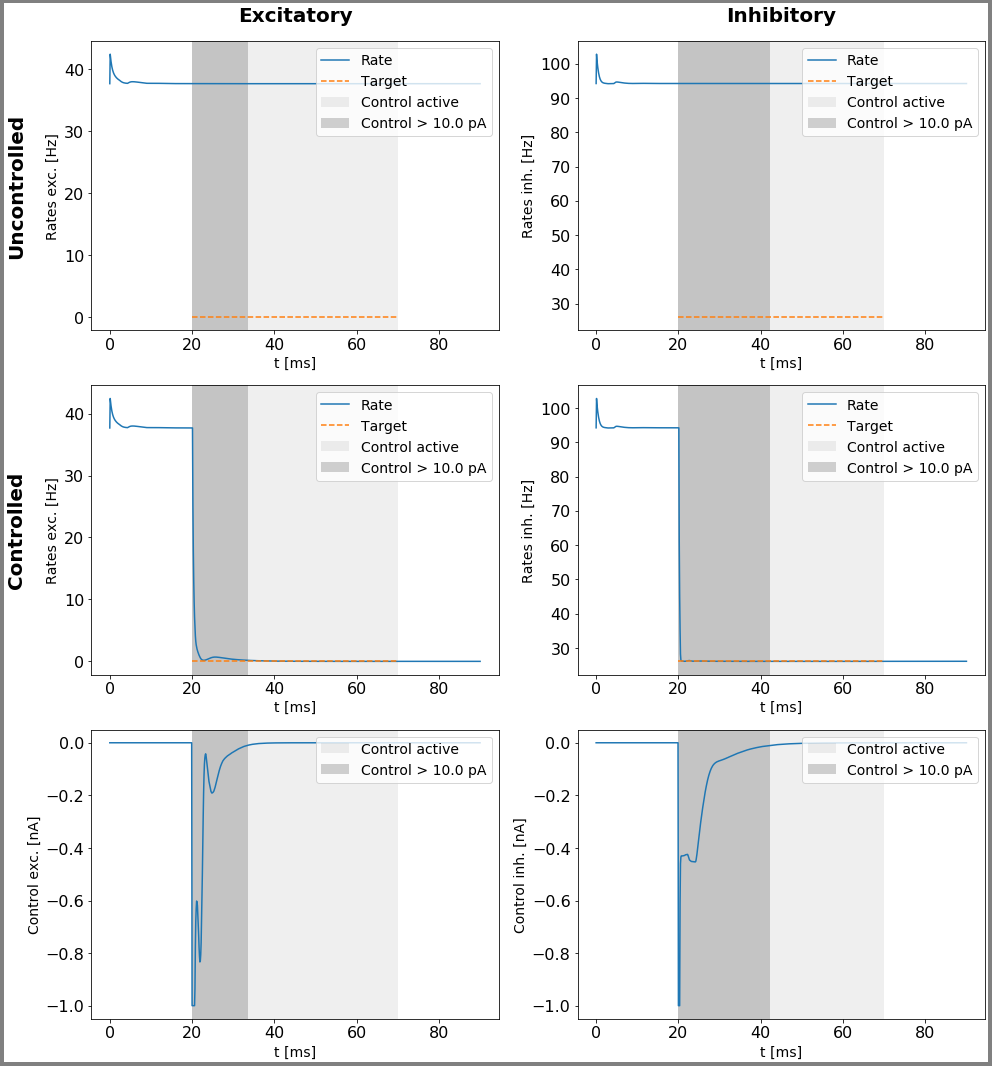

In [18]:
plot_control(A2_bestControlD, dur, dur_pre, dur_post, high_state_vars, target, filename = 'p1_e1_u1nA_HighLow')

### State switching low to high

In [28]:
# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = steady_rates[1,0]
target[:,1,:] = steady_rates[1,1]        

In [29]:
# E: precision only, free choice of control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]             
                
A2_bestControlE, A2_bestStateE, A2_costE, A2_runtimeE = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultE = {"Opt_control": A2_bestControlE,
          "Opt_state": A2_bestStateE,
          "costArray": A2_costE,
          "runtimeArray": A2_runtimeE,    
}

dump_dicts = [opt_params, aln.params, resultE]
pickle.dump( dump_dicts, open( "E.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151756.029461134
RUN  1 , total integrated cost:  7537.593728836044
RUN  2 , total integrated cost:  3084.2867543149805
RUN  3 , total integrated cost:  1844.6635018585218
RUN  4 , total integrated cost:  1400.5957505510942
RUN  5 , total integrated cost:  1044.9623415468113
RUN  6 , total integrated cost:  917.3761994648946
RUN  7 , total integrated cost:  806.2257674398562
RUN  8 , total integrated cost:  762.5583283470716
RUN  9 , total integrated cost:  726.9252004016914
RUN  10 , total integrated cost:  701.8033314084697
RUN  11 , total integrated cost:  681.9553689651751
RUN  12 , total integrated cost:  661.850907534199
RUN  13 , total integrated cost:  653.2520934472192
RUN  14 , total integrated cost:  644.1329822090074
RUN  15 , total integrated cost:  638.3869454048618
RUN  16 , total integrated cost:  631.761602173939
RUN  17 , total integrated cost:  626.739643097689
RUN  18 , total integrated cost:  623.2829

RUN  156 , total integrated cost:  605.7998194854705
RUN  157 , total integrated cost:  605.7998194820714
RUN  158 , total integrated cost:  605.7998194792832
RUN  159 , total integrated cost:  605.7998194766536
RUN  160 , total integrated cost:  605.7998194744816
RUN  161 , total integrated cost:  605.79981947262
RUN  162 , total integrated cost:  605.7998194708044
RUN  163 , total integrated cost:  605.7998194694198
RUN  164 , total integrated cost:  605.7998194681168
RUN  165 , total integrated cost:  605.7998194670363
RUN  166 , total integrated cost:  605.7998194660429
RUN  167 , total integrated cost:  605.7998194652346
RUN  168 , total integrated cost:  605.7998194644241
RUN  169 , total integrated cost:  605.7998194638129
RUN  170 , total integrated cost:  605.7998194632845
RUN  171 , total integrated cost:  605.7998194628113
RUN  172 , total integrated cost:  605.7998194623584
RUN  173 , total integrated cost:  605.7998194619361
RUN  174 , total integrated cost:  605.799819461

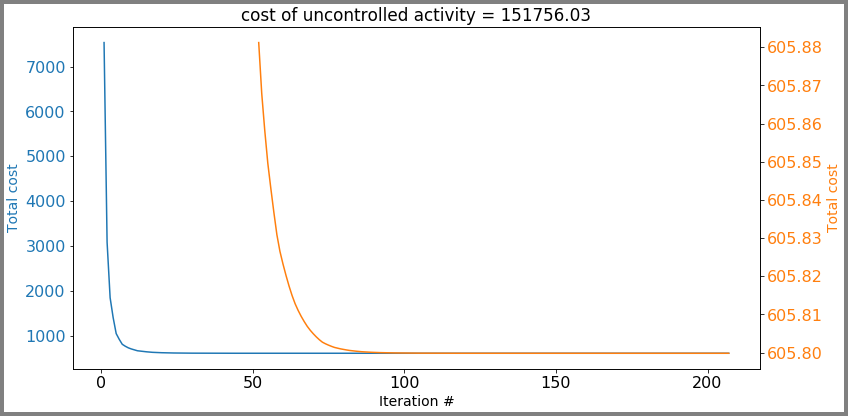

In [30]:
plot_convergence(A2_costE, "p1_e0_uInf_LowHigh_cost")

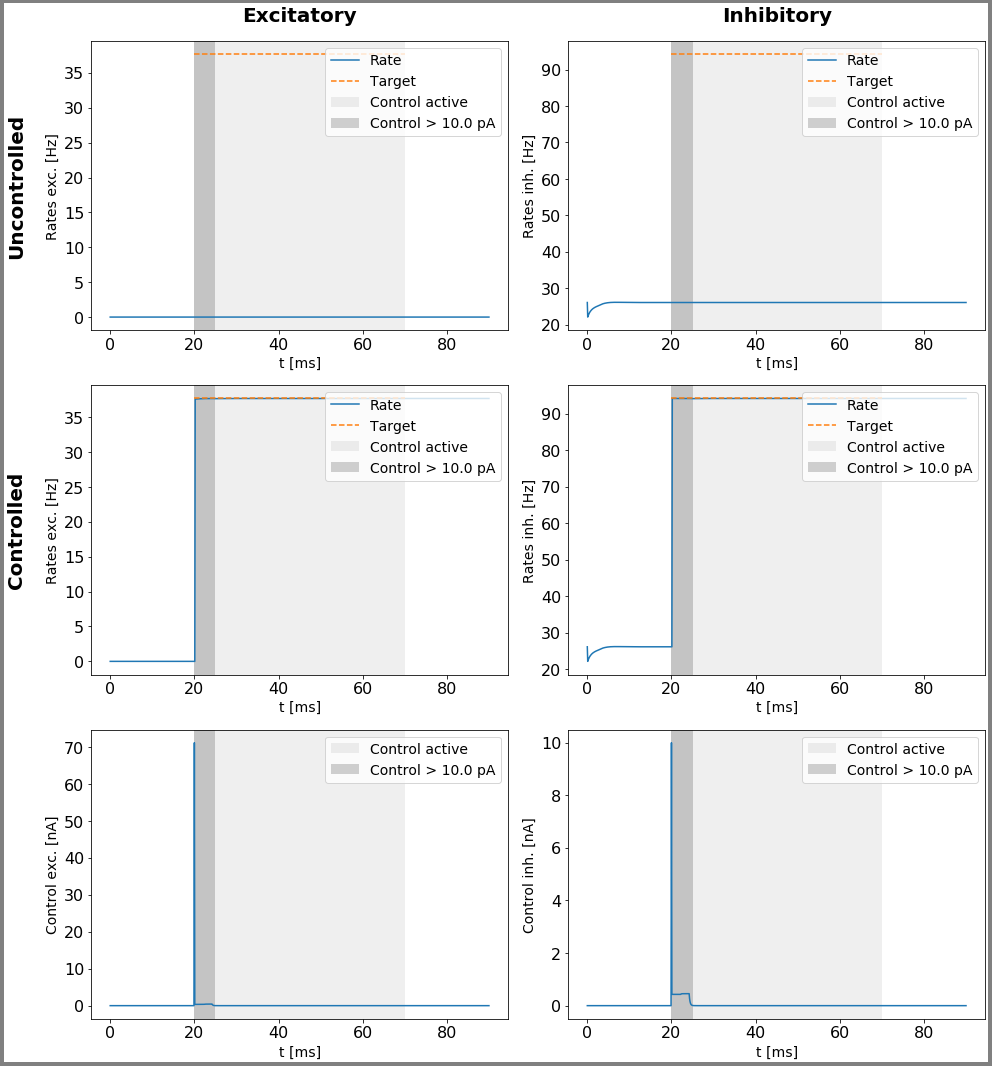

In [31]:
plot_control(A2_bestControlE, dur, dur_pre, dur_post, low_state_vars, target, filename = 'p1_e0_uInf_LowHigh')

In [32]:
# F: precision only, max control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

A2_bestControlF, A2_bestStateF, A2_costF, A2_runtimeF = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultF = {"Opt_control": A2_bestControlF,
          "Opt_state": A2_bestStateF,
          "costArray": A2_costF,
          "runtimeArray": A2_runtimeF,    
}

dump_dicts = [opt_params, aln.params, resultF]
pickle.dump( dump_dicts, open( "F.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151756.19413736317
RUN  1 , total integrated cost:  12502.035286239783
RUN  2 , total integrated cost:  7948.824709226981
RUN  3 , total integrated cost:  5585.817833758237
RUN  4 , total integrated cost:  5238.137633790409
RUN  5 , total integrated cost:  4603.096709821976
RUN  6 , total integrated cost:  4021.2355851459292
RUN  7 , total integrated cost:  3717.745529258001
RUN  8 , total integrated cost:  3589.4974871636987
RUN  9 , total integrated cost:  3476.4452359759835
RUN  10 , total integrated cost:  3380.444827549121
RUN  11 , total integrated cost:  3354.495404818546
RUN  12 , total integrated cost:  3345.797717271549
RUN  13 , total integrated cost:  3339.4235486195607
RUN  14 , total integrated cost:  3332.0688518143256
RUN  15 , total integrated cost:  3328.4406185902176
RUN  16 , total integrated cost:  3325.30206668632
RUN  17 , total integrated cost:  3323.0759156162267
RUN  18 , total integrated cost:  

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  35 , total integrated cost:  3311.9358025355696
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.57772181

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

...

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  192 , total integrated cost:  3311.5212970886946
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  195 , total integrated cost:  3311.521297088632
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.57772181

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  198 , total integrated cost:  3311.5212970885955
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  201 , total integrated cost:  3311.5212970885736
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  204 , total integrated cost:  3311.5212970885636
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218

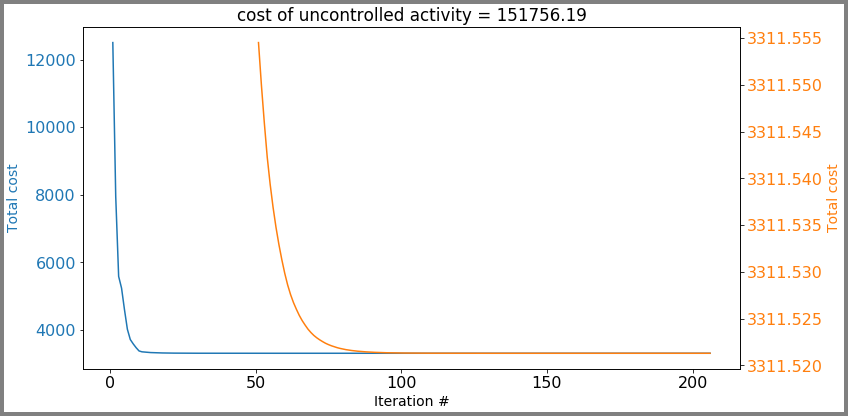

In [33]:
plot_convergence(A2_costF, "p1_e0_u1nA_LowHigh_cost")

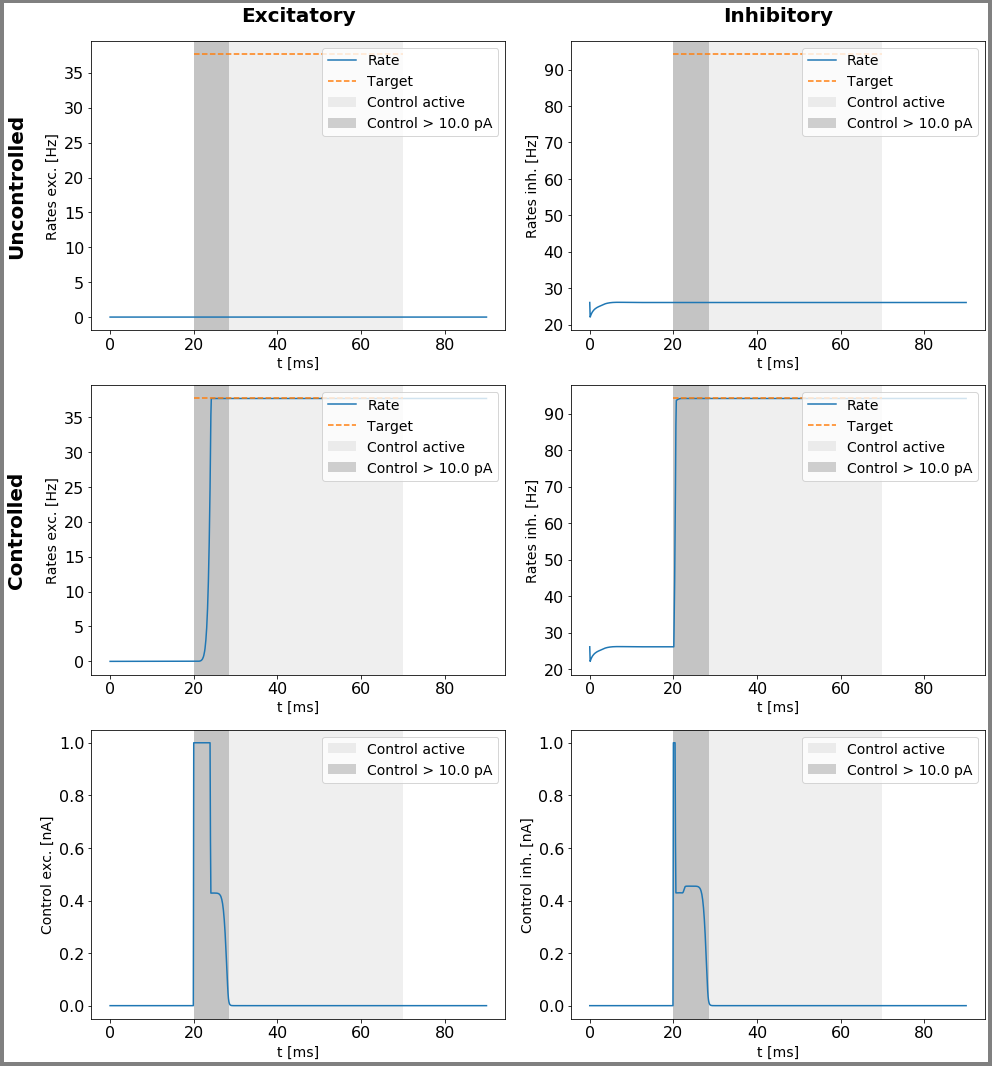

In [34]:
plot_control(A2_bestControlF, dur, dur_pre, dur_post, low_state_vars, target, filename = 'p1_e0_u1nA_LowHigh')

In [35]:
# G: precision and energy equally, free choice of control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

A2_bestControlG, A2_bestStateG, A2_costG, A2_runtimeG = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultG = {"Opt_control": A2_bestControlG,
          "Opt_state": A2_bestStateG,
          "costArray": A2_costG,
          "runtimeArray": A2_runtimeG,    
}

dump_dicts = [opt_params, aln.params, resultG]
pickle.dump( dump_dicts, open( "G.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151756.19413752644
RUN  1 , total integrated cost:  20157.034220209498
RUN  2 , total integrated cost:  6552.995981736251
RUN  3 , total integrated cost:  3945.2028357165636
RUN  4 , total integrated cost:  3391.3667338126784
RUN  5 , total integrated cost:  2885.721514571338
RUN  6 , total integrated cost:  2589.3645970677653
RUN  7 , total integrated cost:  2140.6876791551613
RUN  8 , total integrated cost:  1942.3595542505943
RUN  9 , total integrated cost:  1842.7025326091816
RUN  10 , total integrated cost:  1785.8438894947915
RUN  11 , total integrated cost:  1709.9005626824612
RUN  12 , total integrated cost:  1618.7553246339749
RUN  13 , total integrated cost:  1571.0215035214399
RUN  14 , total integrated cost:  1545.589619007622
RUN  15 , total integrated cost:  1519.3997703922475
RUN  16 , total integrated cost:  1487.39525347642
RUN  17 , total integrated cost:  1459.089607695492
RUN  18 , total integrated cos

RUN  154 , total integrated cost:  1320.4987647353416
RUN  155 , total integrated cost:  1320.4939079796277
RUN  156 , total integrated cost:  1320.4901399694145
RUN  157 , total integrated cost:  1320.4874146457798
RUN  158 , total integrated cost:  1320.484188008985
RUN  159 , total integrated cost:  1320.480408546005
RUN  160 , total integrated cost:  1320.4759083092229
RUN  161 , total integrated cost:  1320.471907877361
RUN  162 , total integrated cost:  1320.468491893929
RUN  163 , total integrated cost:  1320.4653042523753
RUN  164 , total integrated cost:  1320.4625256749794
RUN  165 , total integrated cost:  1320.4595245439841
RUN  166 , total integrated cost:  1320.4567681087844
RUN  167 , total integrated cost:  1320.4537705215103
RUN  168 , total integrated cost:  1320.450794691859
RUN  169 , total integrated cost:  1320.448108948386
RUN  170 , total integrated cost:  1320.4455953209915
RUN  171 , total integrated cost:  1320.4432863749034
RUN  172 , total integrated cost: 

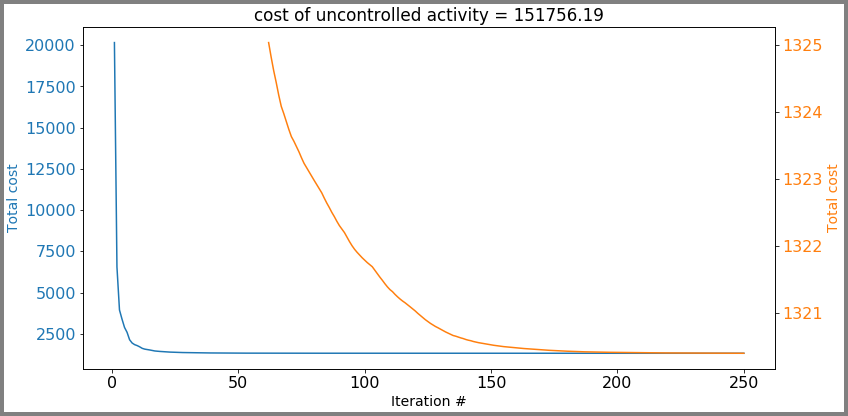

In [36]:
plot_convergence(A2_costG, "p1_e1_uInf_LowHigh_cost")

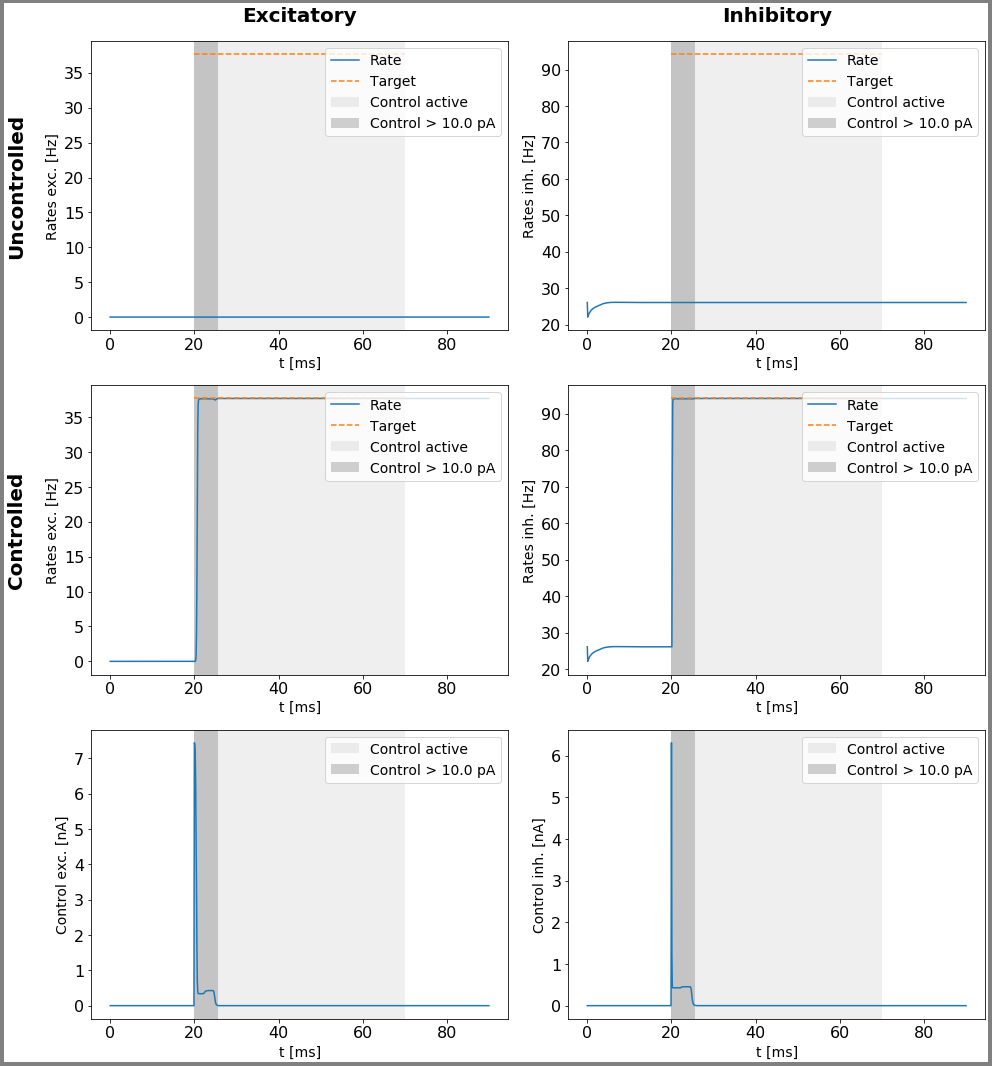

In [37]:
plot_control(A2_bestControlG, dur, dur_pre, dur_post, low_state_vars, target, filename = 'p1_e1_uInf_LowHigh')

In [38]:
# F: precision and energy equally, max control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

A2_bestControlH, A2_bestStateH, A2_costH, A2_runtimeH = aln.A2(control0, target, max_iteration_ = max_it, tolerance_ = tol,
                include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultH = {"Opt_control": A2_bestControlH,
          "Opt_state": A2_bestStateH,
          "costArray": A2_costH,
          "runtimeArray": A2_runtimeH,    
}

dump_dicts = [opt_params, aln.params, resultH]
pickle.dump( dump_dicts, open( "H.p", "wb" ) )

set cost params
start ind =  41
RUN  0 , total integrated cost:  151756.19413752196
RUN  1 , total integrated cost:  13077.05554895155
RUN  2 , total integrated cost:  8580.660568825566
RUN  3 , total integrated cost:  6096.30121668932
RUN  4 , total integrated cost:  5645.367318276362
RUN  5 , total integrated cost:  4932.269709538449
RUN  6 , total integrated cost:  4346.46074374257
RUN  7 , total integrated cost:  4009.768933394168
RUN  8 , total integrated cost:  3860.987990962042
RUN  9 , total integrated cost:  3716.3894736572806
RUN  10 , total integrated cost:  3525.5622173942597
RUN  11 , total integrated cost:  3465.1674347050825
RUN  12 , total integrated cost:  3449.4814209421374
RUN  13 , total integrated cost:  3437.8647449445484
RUN  14 , total integrated cost:  3423.3939683428293
RUN  15 , total integrated cost:  3418.0794477698864
RUN  16 , total integrated cost:  3413.4181739569535
RUN  17 , total integrated cost:  3409.9119428149374
RUN  18 , total integrated cost:  

RUN  32 , total integrated cost:  3394.1066736232196
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.57772181

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  36 , total integrated cost:  3393.663559936386
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.577721810

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
RUN  43 , total integrated cost:  3393.3

...

 max iteration reached, step size =  1.5777218104420236e-27
RUN  161 , total integrated cost:  3393.259438771188
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.57772181

RUN  164 , total integrated cost:  3393.2594387709605
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218

RUN  167 , total integrated cost:  3393.259438770874
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.57772181

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5777218104420236e-27
 max iteration reached, step size =  1.5

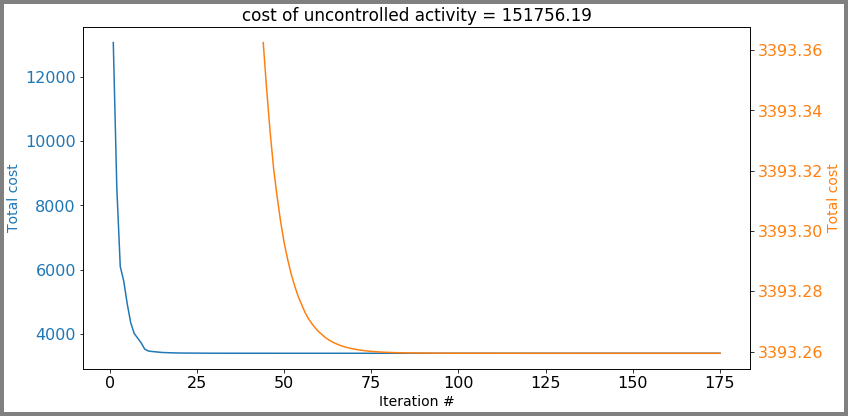

In [39]:
plot_convergence(A2_costH, "p1_e1_u1nA_LowHigh_cost")

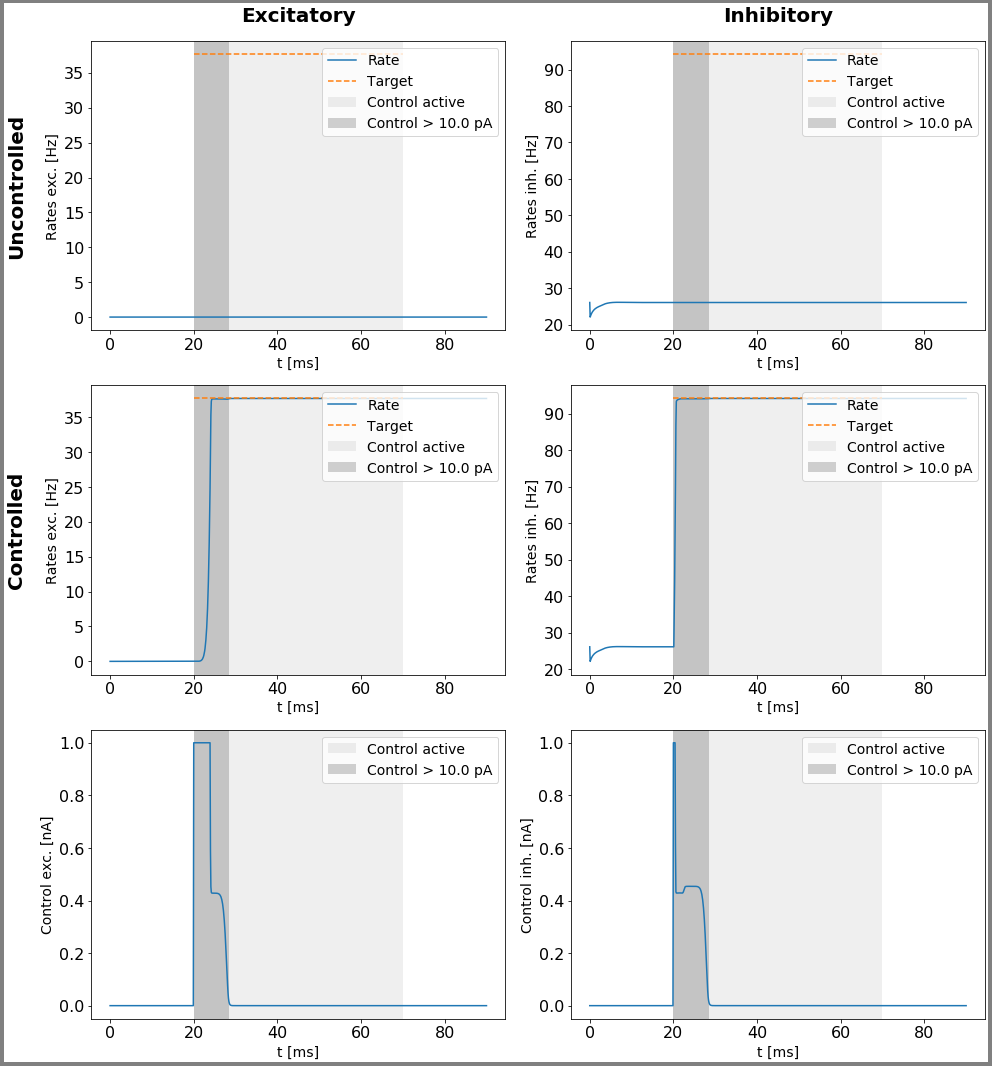

In [40]:
plot_control(A2_bestControlH, dur, dur_pre, dur_post, low_state_vars, target, filename = 'p1_e1_u1nA_LowHigh')

### Force into other rhythm in oscillatory regime

In [ ]:
aln = ALNModel()

aln.params['duration'] = 100.
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

control0 = aln.getZeroControl()

aln.params.ext_exc_current = 0.4 # increasing current to excitatory in rows
aln.params.ext_inh_current = 0.0 # increasing current to inhibitory in columns
# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.mue_ext_mean = 0.0 # increasing current to excitatory in rows
aln.params.mui_ext_mean = 0.0 # increasing current to inhibitory in columns

output = aln.output_vars
aln.run()

print("Externat current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)
fig, ax = plt.subplots(1, 2 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for i in range(2):
    ax[i].plot(aln.t, aln[output[i]][0,:] )
    ax[i].set(xlabel='t [ms]', ylabel=output[i])
plt.show()
print("-------------------------------------------")

# set this excitatory rate as target
target = aln.getZeroTarget()
target[:,0,:] = aln[output[0]]
target[:,1,:] = aln[output[1]]

aln.params.ext_exc_current = 0.7 # increasing current to excitatory in rows
aln.run()

print("Externat current: exc = ", aln.params.ext_exc_current, ", inh = ", aln.params.ext_inh_current)
fig, ax = plt.subplots(1, 2 , figsize=(10, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
for i in range(2):
    ax[i].plot(aln.t, aln[output[i]][0,:] )
    ax[i].set(xlabel='t [ms]', ylabel=output[i])
plt.show()
print("-------------------------------------------")

In [ ]:
state = aln.getZeroState()
aln.run()
output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]]

A2_bestControl, A2_bestState, A2_cost, A2_runtime = aln.A2(control0, target, max_iteration_ = 10, tolerance_ = 1e-12,
                include_timestep_ = 30, start_step_ = 10., test_step_ = 1e-6, max_control_ = 100.)

In [ ]:
A2_bestControl1, A2_bestState1, A2_cost1, A2_runtime1 = aln.A2(A2_bestControl, target, max_iteration_ = 1, tolerance_ = 1e-12,
                include_timestep_ = 1000, start_step_ = 1000., test_step_ = 1e-6, max_control_ = 100.)

In [ ]:
control1 = control0.copy()
control1[0,0,:] = -0.3

A2_bestControl2, A2_bestState2, A2_cost2, A2_runtime2 = aln.A2(control1, target, max_iteration_ = 2, tolerance_ = 1e-12,
                include_timestep_ = 10, start_step_ = 10., test_step_ = 1e-6, max_control_ = 100.)

In [ ]:
plot_control(A2_bestControl1, target)

In [ ]:
aln = ALNModel()
aln.params['duration'] = 5. * 1000.
#aln.params.signalV = 0.
#aln.params.de = 0.
#aln.params.di = 0.
len_time = int(round(aln.params.duration/aln.params.dt,1)+1)
control0 = aln.getZeroControl()

for i in range(int(0.0*len_time), int(0.05*len_time), 1):
    control0[0,:,i] = -6.
for i in range(int(0.25*len_time), int(0.3*len_time), 1):
    control0[0,:,i] = -2.
for i in range(int(0.5*len_time), int(0.55*len_time), 1):
    control0[0,:,i] = 2.    
for i in range(int(0.75*len_time), int(0.8*len_time), 1):
    control0[0,:,i] = 6. 

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0 # increasing current to excitatory in rows
aln.params.mui_ext_mean = 0.0 # increasing current to inhibitory in columns

incr = 10
fig,ax = plt.subplots(incr, incr, figsize=(50, 50))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)

starte = 1.905
starti = 1.665
step = 0.02
for i in range(incr):
    for j in range(incr):
        # exc 2.05
        # inh 1.7
        exc_current = starte + (j * step)
        inh_current = starti + (i * step)
        aln.params.ext_exc_current = exc_current # increasing current to excitatory in rows
        aln.params.ext_inh_current = inh_current # increasing current to inhibitory in columns
        aln.run(control = control0)
    
        ax[i,j].set_title(str('exc = ' + str(exc_current) + ', inh = ' + str(inh_current) + ' ( ' + str(exc_current/5.)
                              + ', ' +  str(inh_current/5.) + ')'))
        ax[i,j].plot(aln['t'], aln['rates_exc'].T, lw=1, c=cpalette[0], label = "Rate of excitatory population")
        ax[i,j].plot(aln['t'], aln['rates_inh'].T, lw=1, c=cpalette[-1], label = "Rate of inhibitory population")
        #ax[i,j].set_ylabel("Rate [Hz]")
        #ax[i,j].set_xlabel("t [ms]")
        #ax[i,j].legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), shadow=True, ncol=1)

        #ax2 = ax[i,j].twinx()
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control exc")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control inh")
        #ax2.plot(aln['t'], aln['IA'].T, lw=1, c=cpalette[1], label = "Adaptation current")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[-2], linestyle="dashed", label = "Control: External current (exc)")

        #ax2.set_ylabel("Adaptation and input current (exc)")
        #ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), shadow=True, ncol=1)
        
#plt.xlim(1000, 2000)
plt.savefig('parameter_space.png')

In [ ]:
incr = 10
fig,ax = plt.subplots(incr, incr, figsize=(100, 100))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)

starte = 1.6
starti = 1.2
step = 0.1
for i in range(10):
    for j in range(10):
        exc_current = starte + (j * step)
        inh_current = starti + (i * step)
        aln.params.ext_exc_current = exc_current # increasing current to excitatory in rows
        aln.params.ext_inh_current = inh_current # increasing current to inhibitory in columns
        aln.run(control = control0)
    
        ax[i,j].set_title(str('exc = ' + str(exc_current) + ', inh = ' + str(inh_current) 
                              + ' ( ' + str(exc_current/5.) + ', ' +  str(inh_current/5.) + ')'))
        ax[i,j].plot(aln['t'], aln['rates_exc'].T, lw=1, c=cpalette[0], label = "Rate of excitatory population")
        ax[i,j].plot(aln['t'], aln['rates_inh'].T, lw=1, c=cpalette[-1], label = "Rate of inhibitory population")
        #ax[i,j].set_ylabel("Rate [Hz]")
        #ax[i,j].set_xlabel("t [ms]")
        #ax[i,j].legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), shadow=True, ncol=1)

        #ax2 = ax[i,j].twinx()
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control exc")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[1], label = "Control inh")
        #ax2.plot(aln['t'], aln['IA'].T, lw=1, c=cpalette[1], label = "Adaptation current")
        #ax2.plot(aln['t'], control0[0,0,:], lw=1, c=cpalette[-2], linestyle="dashed", label = "Control: External current (exc)")

        #ax2.set_ylabel("Adaptation and input current (exc)")
        #ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), shadow=True, ncol=1)
        
#plt.xlim(1000, 2000)
plt.savefig('parameter_space1.png')